# Scenario Analysis: France

In [29]:
# Imports
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

We read the dataset files into pandas dataframes, for co2 emissions, demand and the photovoltaic production

In [30]:
co2_df = pd.read_csv("FR/co2.csv", names=["CO2/Kwh"])
demand_df = pd.read_csv("FR/demand.csv", names=["demand"])
pv_df = pd.read_csv("FR/pv.csv", names=["pv_kw"])

### Visualizing the data (Monthly)

#### CO2 Emissions

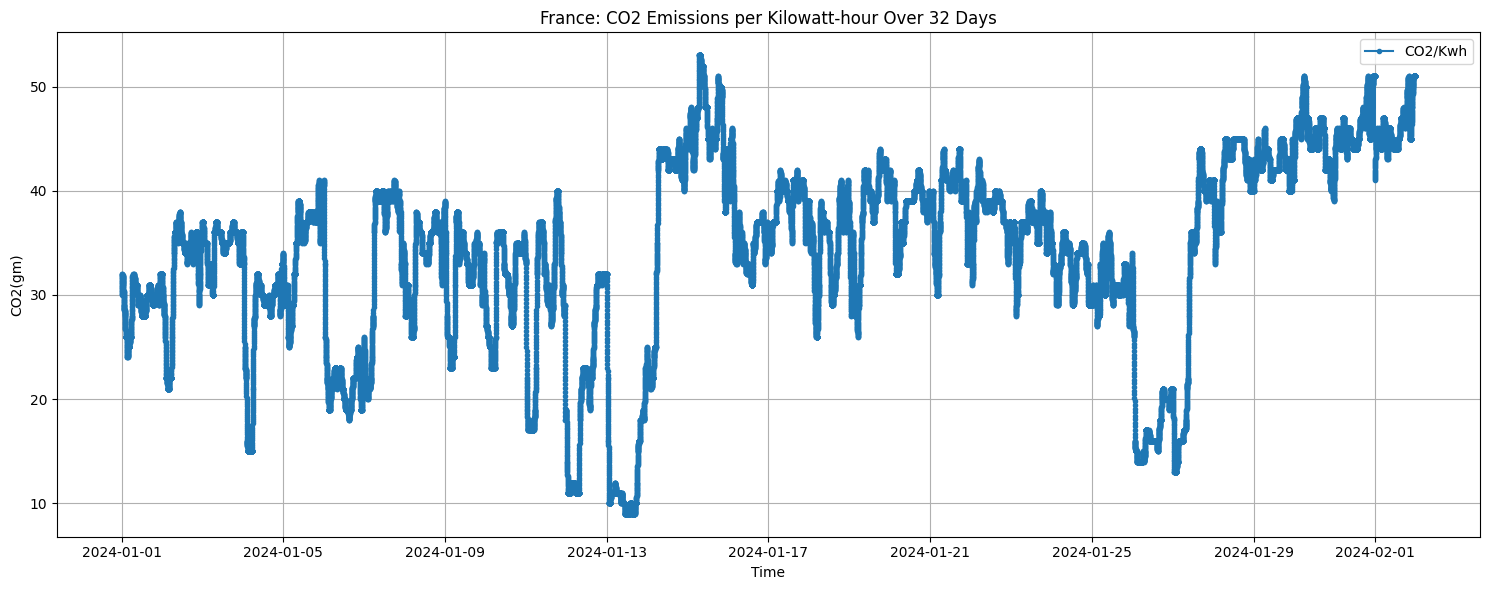

In [31]:
time_index = pd.date_range(start='2024-01-01', periods=len(co2_df['CO2/Kwh']), freq='1T')
# Plot the data
plt.figure(figsize=(15, 6))
plt.plot(time_index, co2_df['CO2/Kwh'], linestyle='-', marker='o', markersize=3, label='CO2/Kwh')
plt.xlabel('Time')
plt.ylabel('CO2(gm)')
plt.title('France: CO2 Emissions per Kilowatt-hour Over 32 Days')
plt.grid(True)
plt.legend()
plt.tight_layout()

#### Electricity Demand

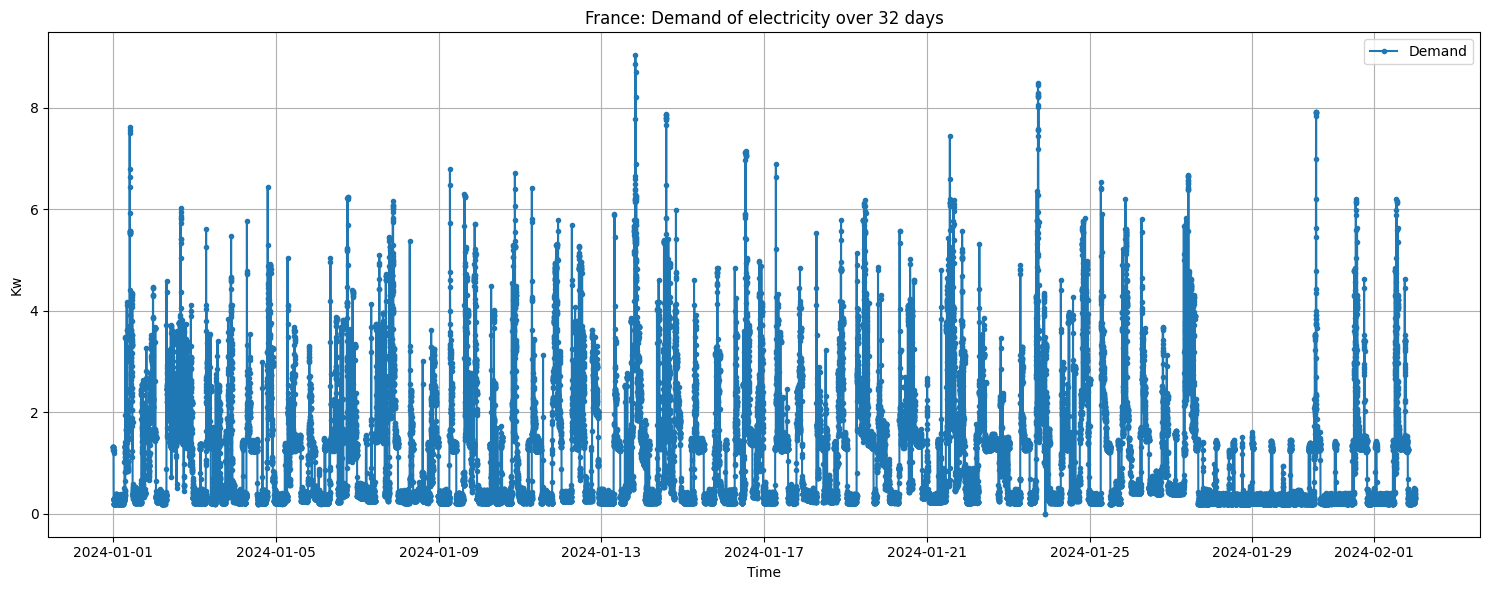

In [32]:
time_index = pd.date_range(start='2024-01-01', periods=len(demand_df['demand']), freq='1T')
# Plot the data
plt.figure(figsize=(15, 6))
plt.plot(time_index, demand_df['demand'], linestyle='-', marker='o', markersize=3, label='Demand')
plt.xlabel('Time')
plt.ylabel('Kw')
plt.title('France: Demand of electricity over 32 days')
plt.grid(True)
plt.legend()
plt.tight_layout()

#### Photovoltaic Production

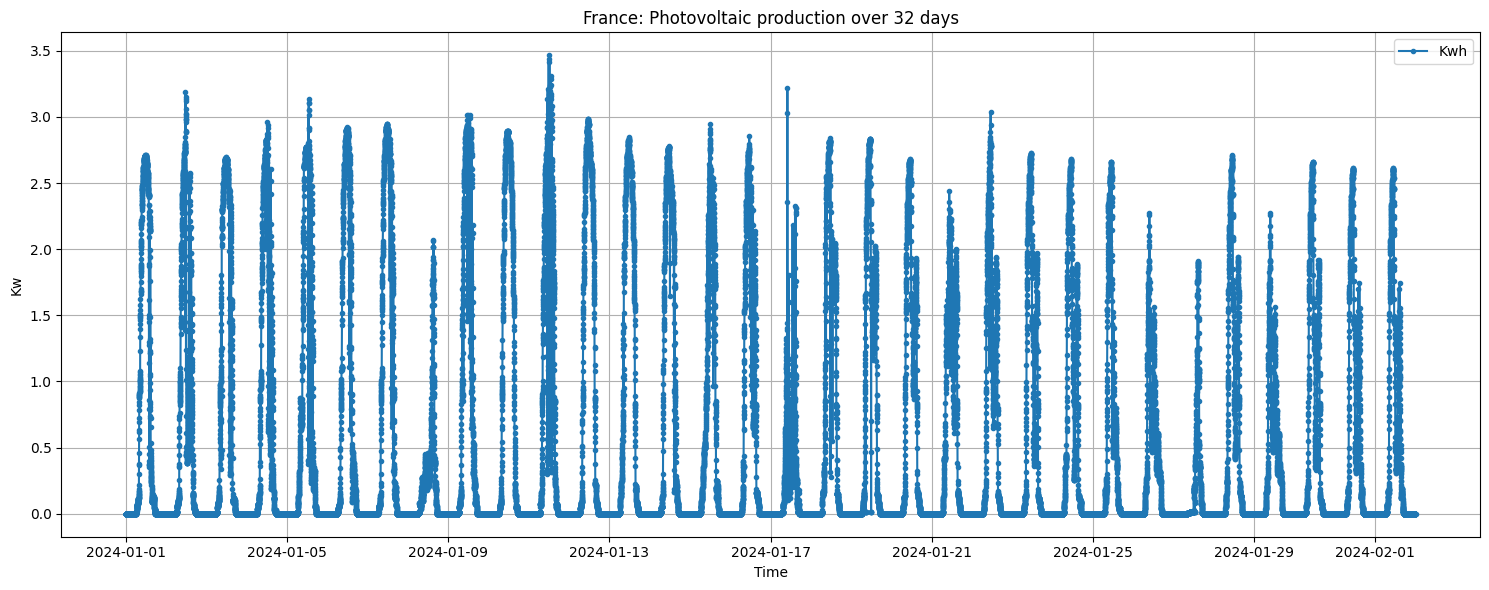

In [33]:
time_index = pd.date_range(start='2024-01-01', periods=len(pv_df["pv_kw"]), freq='1T')
# Plot the data
plt.figure(figsize=(15, 6))
plt.plot(time_index, pv_df["pv_kw"], linestyle='-', marker='o', markersize=3, label='Kwh')
plt.xlabel('Time')
plt.ylabel('Kw')
plt.title('France: Photovoltaic production over 32 days')
plt.grid(True)
plt.legend()
plt.tight_layout()

### Visualizing the data (24 Hours)

#### Photovoltaic Production

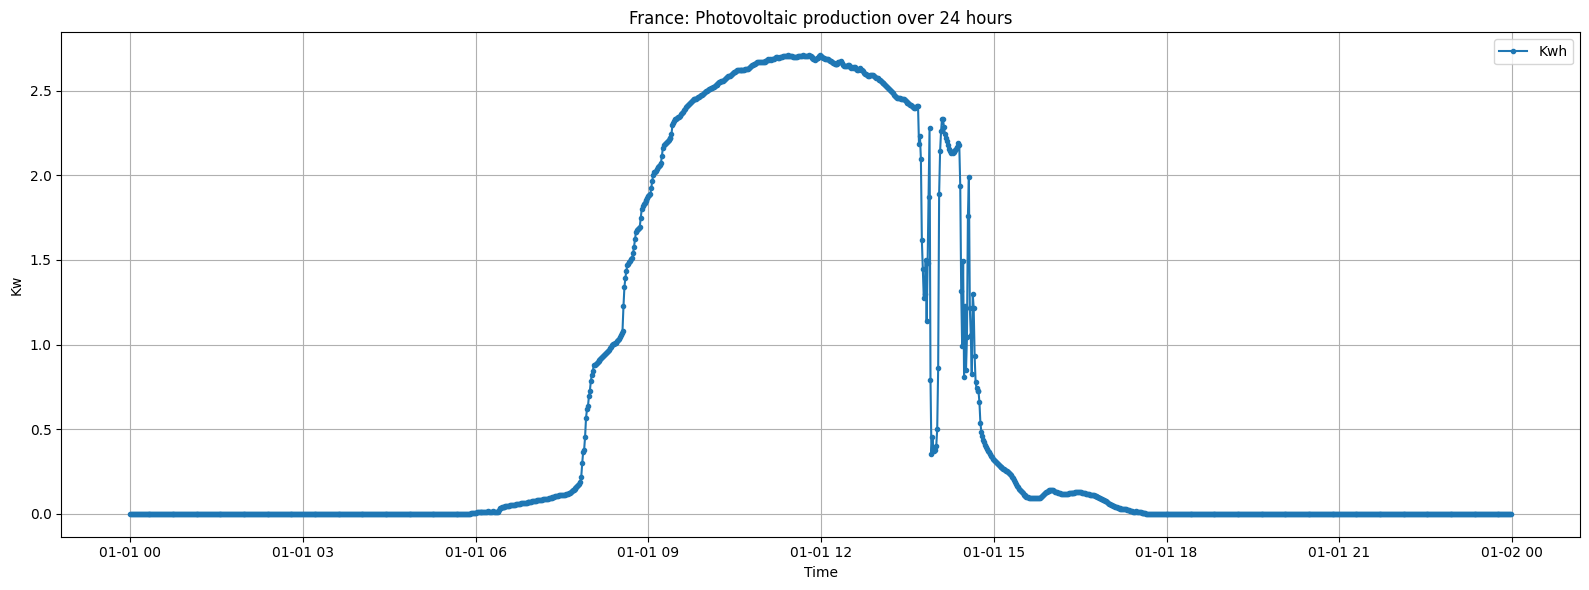

In [34]:
data = pd.read_csv('FR/pv.csv',header=None, names=['pv_kw'])
data_one_day = data.iloc[:24 * 60]

time_index = pd.date_range(start='2024-01-01', periods=len(data_one_day), freq='1T')
# Plot the data
plt.figure(figsize=(16, 6))
plt.plot(time_index, data_one_day, linestyle='-', marker='o', markersize=3, label='Kwh')
plt.xlabel('Time')
plt.ylabel('Kw')
plt.title('France: Photovoltaic production over 24 hours')
plt.grid(True)
plt.legend()
plt.tight_layout()

#### Electricity Demand

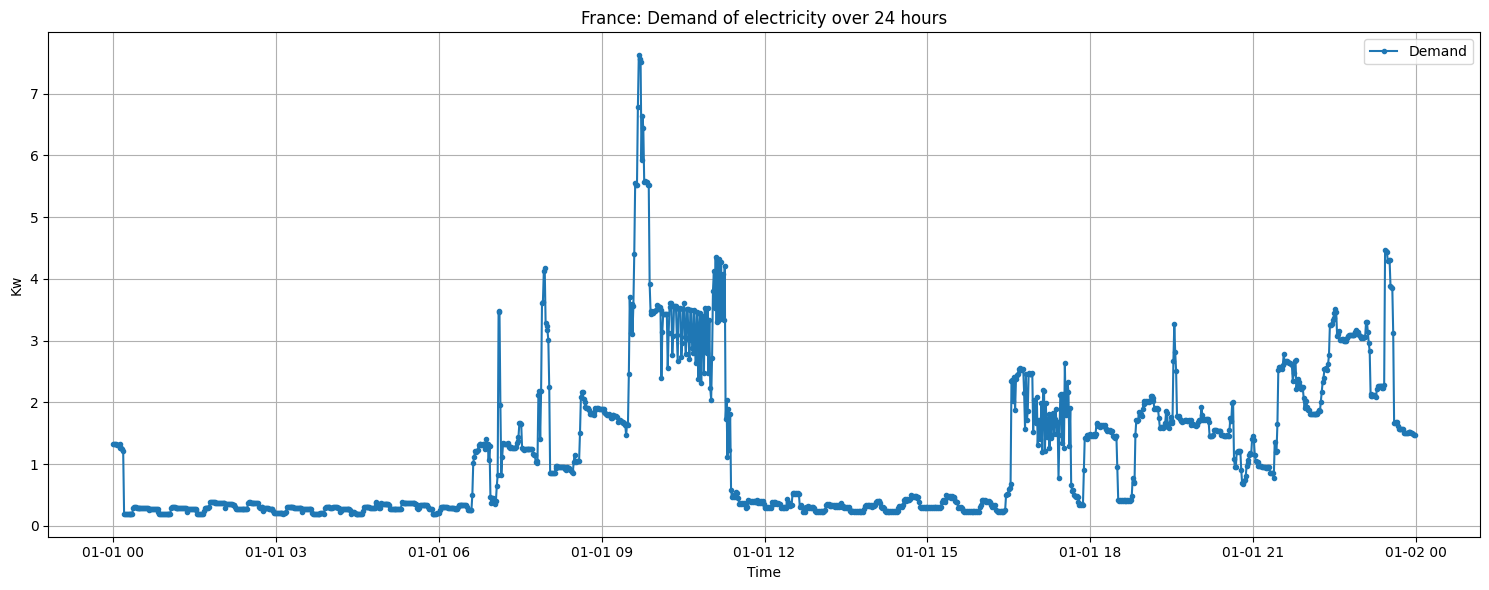

In [35]:
data = pd.read_csv('FR/demand.csv',header=None, names=['demand'])
data_one_day = data.iloc[0:24*60]

time_index = pd.date_range(start='2024-01-01', periods=len(data_one_day), freq='1T')
# Plot the data
plt.figure(figsize=(15, 6))
plt.plot(time_index, data_one_day, linestyle='-', marker='o', markersize=3, label='Demand')
plt.xlabel('Time')
plt.ylabel('Kw')
plt.title('France: Demand of electricity over 24 hours')
plt.grid(True)
plt.legend()
plt.tight_layout()

#### CO2 Emissions

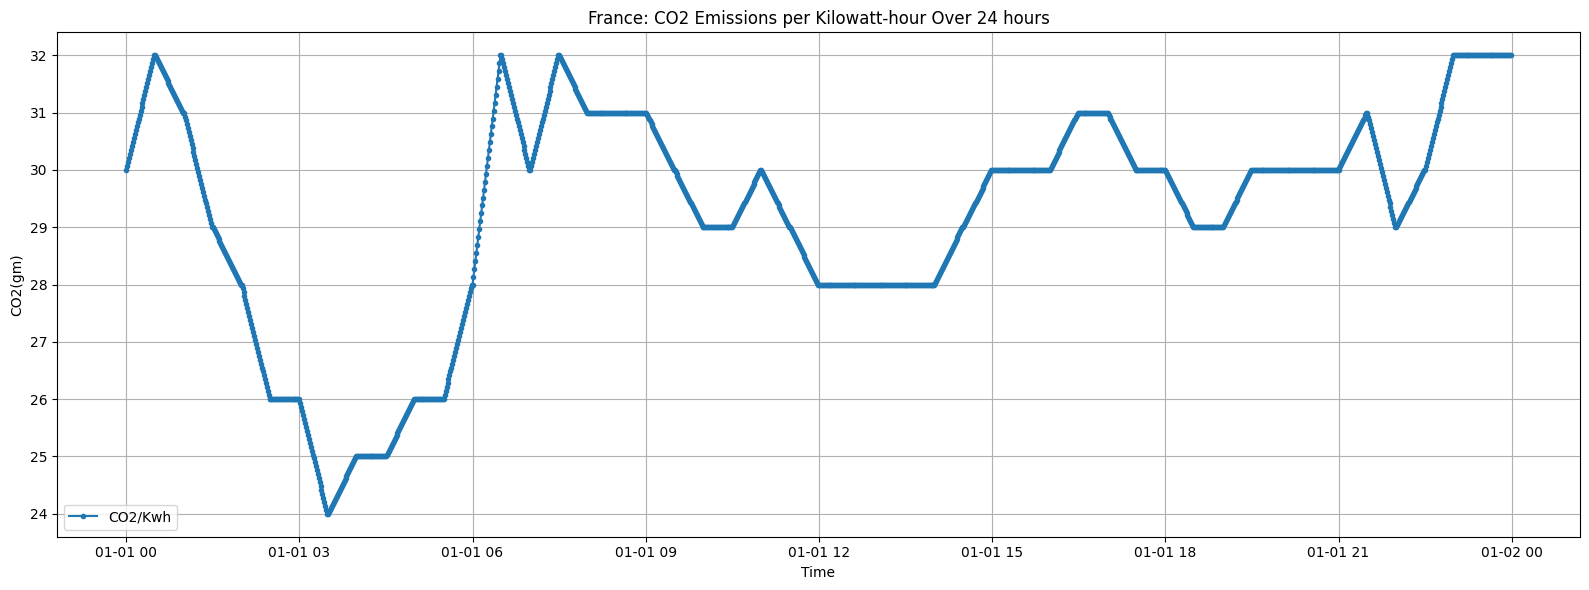

In [36]:
data = pd.read_csv('FR/co2.csv',header=None, names=['CO2/Kwh'])
data_one_day = data.iloc[0:24*60]

time_index = pd.date_range(start='2024-01-01', periods=len(data_one_day), freq='1T')
# Plot the data
plt.figure(figsize=(16, 6))
plt.plot(time_index, data_one_day, linestyle='-', marker='o', markersize=3, label='CO2/Kwh')
plt.xlabel('Time')
plt.ylabel('CO2(gm)')
plt.title('France: CO2 Emissions per Kilowatt-hour Over 24 hours')
plt.grid(True)
plt.legend()
plt.tight_layout()

### Analyzing the scenarios

#### Scenario One
In this scenario we meet the demand only through the grid.

In [37]:
electricity_cost = 0.003862

result_df_grid_1 = pd.DataFrame(co2_df.values*demand_df.values)
time_index_1 = pd.date_range(start='2024-01-01', periods=len(result_df_grid_1), freq='1T')

cost_df_1 = pd.DataFrame(electricity_cost*demand_df.values)
time_index_1C = pd.date_range(start='2024-01-01', periods=len(cost_df_1), freq='1T')

value = result_df_grid_1.sum()[0]
print(f'Co2 Emissions: {value:,}')
print(f'Total electricity usage: {demand_df.sum()[0]:,}')

Co2 Emissions: 1,730,536.553586207
Total electricity usage: 50,559.579999999994


/var/folders/nw/y1x5c01x11l4zqclcx59zjpm0000gn/T/ipykernel_69958/2556378321.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f'Total electricity usage: {demand_df.sum()[0]:,}')


#### Scenario Two
In this scenario we meet the demand through the grid and the PV. If the PV produces excess it is sold back to the grid.

In [38]:
net_kw_df = demand_df.values - pv_df.values
excess_df = net_kw_df[net_kw_df < 0]
net_kw_df[net_kw_df < 0] = 0

result_df_grid_2 = pd.DataFrame(co2_df.values*net_kw_df)
time_index_2 = pd.date_range(start='2024-01-01', periods=len(result_df_grid_2), freq='1T')

cost_df_2 = pd.DataFrame(electricity_cost*net_kw_df)
time_index_2C = pd.date_range(start='2024-01-01', periods=len(cost_df_2), freq='1T')

value = result_df_grid_2.sum()[0]
print(f'Co2 Emissions: {value:,}')
print(f'Total electricity usage: {net_kw_df.sum():,}')
print(f'Total pv excess: {abs(excess_df.sum()):,}')

Co2 Emissions: 1,256,405.7368611412
Total electricity usage: 36,867.47193296881
Total pv excess: 10,397.478849381372


#### Scenario Three
In this scenario the demand is met through the grid, battery and the PV. If the PV produces excess, it is used to charge the battery. If there is still excess, it is sold back to the grid.

In [39]:
import pandas as pd

co2_df = pd.read_csv('FR/co2.csv')
demand_df = pd.read_csv('FR/demand.csv')
pv_df = pd.read_csv('FR/pv.csv')

co2_values = co2_df.iloc[:, 0].tolist()
demand_values = demand_df.iloc[:, 0].tolist()
pv_values = pv_df.iloc[:, 0].tolist()

net_kw = []
battery_storage = 0
battery_limit = 13.5
excess = 0
for i in range(len(co2_values)):
    net_value = demand_values[i] - pv_values[i]
    if net_value < 0:
        battery_storage += abs(net_value)
        if battery_storage > 13.5:
            excess += (battery_storage - battery_limit)
            battery_storage = 13.5
        net_kw.append(0)
    else:
        if battery_storage >= net_value:
            battery_storage -= net_value
            net_kw.append(0)
        else:
            net_kw.append(net_value - battery_storage)
            battery_storage = 0

total_co2 = sum(co2 * kw for co2, kw in zip(co2_values, net_kw))

result_df_grid_3 = pd.DataFrame(co2 * kw for co2, kw in zip(co2_values, net_kw))
time_index_3 = pd.date_range(start='2024-01-01', periods=len(result_df_grid_3), freq='1T')

net_kw_df = pd.DataFrame(net_kw)
cost_df_3 = pd.DataFrame(electricity_cost*net_kw_df)
time_index_3C = pd.date_range(start='2024-01-01', periods=len(cost_df_3), freq='1T')

print(f'Co2 emissions: {total_co2:,}')
print(f'Total electricity usage: {sum(net_kw):,}')
print(f'Total pv excess: {excess:,}')

Co2 emissions: 1,220,738.0618885437
Total electricity usage: 35,845.75622267961
Total pv excess: 9,377.087139095187


#### Scenario Four
In this case, the third scenario is further optimized. The battery is charged when the CO2 emissions from the grid is low, and when the CO2 emissions are high, the demand is met from the battery, PV and at last the grid. The cutoff is determined by a CO2 emissions threshold value.

The threshold value is selected by looping the optimization function through varying threshold range, starting minimum CO2 emissions upto highest CO2 emissions.

In [40]:
# Constants
BATTERY_LIMIT = 13.5
CO2_THRESHOLD = 33
CHARGING_RATE_MIN = 0.05

co2_df = pd.read_csv('FR/co2.csv')
demand_df = pd.read_csv('FR/demand.csv')
pv_df = pd.read_csv('FR/pv.csv')

co2_values = co2_df.iloc[:, 0].tolist()
demand_values = demand_df.iloc[:, 0].tolist()
pv_values = pv_df.iloc[:, 0].tolist()

net_kw = []
battery_storage = 0
excess = 0
charging_draw_co2 = 0
charging_draw_electricity = 0

for i in range(len(co2_values)):
    net_value = demand_values[i] - pv_values[i]

    if net_value < 0:
        battery_storage += abs(net_value)
        if battery_storage > BATTERY_LIMIT:
            excess += (battery_storage - BATTERY_LIMIT)
            battery_storage = BATTERY_LIMIT
    else:
        if co2_values[i] > CO2_THRESHOLD:
            deficit = min(battery_storage, abs(net_value))
            battery_storage -= deficit
            net_kw.append(net_value - deficit)
        else:
            deficit = min(battery_storage, abs(net_value))
            battery_storage -= deficit
            net_kw.append(net_value - deficit)

            if battery_storage < BATTERY_LIMIT:
                charging_draw = min(BATTERY_LIMIT - battery_storage, CHARGING_RATE_MIN)
                battery_storage += charging_draw
                charging_draw_electricity += charging_draw_electricity
                charging_draw_co2 += charging_draw * co2_values[i]

total_co2 = sum(co2 * kw for co2, kw in zip(co2_values, net_kw)) + charging_draw_co2
total_usage = sum(net_kw) + charging_draw_electricity
total_excess = excess

result_df_grid_4 = pd.DataFrame(co2 * kw for co2, kw in zip(co2_values, net_kw))
time_index_4 = pd.date_range(start='2024-01-01', periods=len(result_df_grid_4), freq='1T')

net_kw_df = pd.DataFrame(net_kw)
cost_df_4 = pd.DataFrame(electricity_cost*net_kw_df)
time_index_4C = pd.date_range(start='2024-01-01', periods=len(cost_df_4), freq='1T')

print(f'Co2 emissions: {total_co2:,}')
print(f'Total electricity usage: {total_usage:,}')
print(f'Total pv excess: {total_excess:,}')

Co2 emissions: 1,167,608.8078420737
Total electricity usage: 35,136.84743015662
Total pv excess: 9,386.953368406037


### Visualizing the scenarios

#### CO2 Emissions

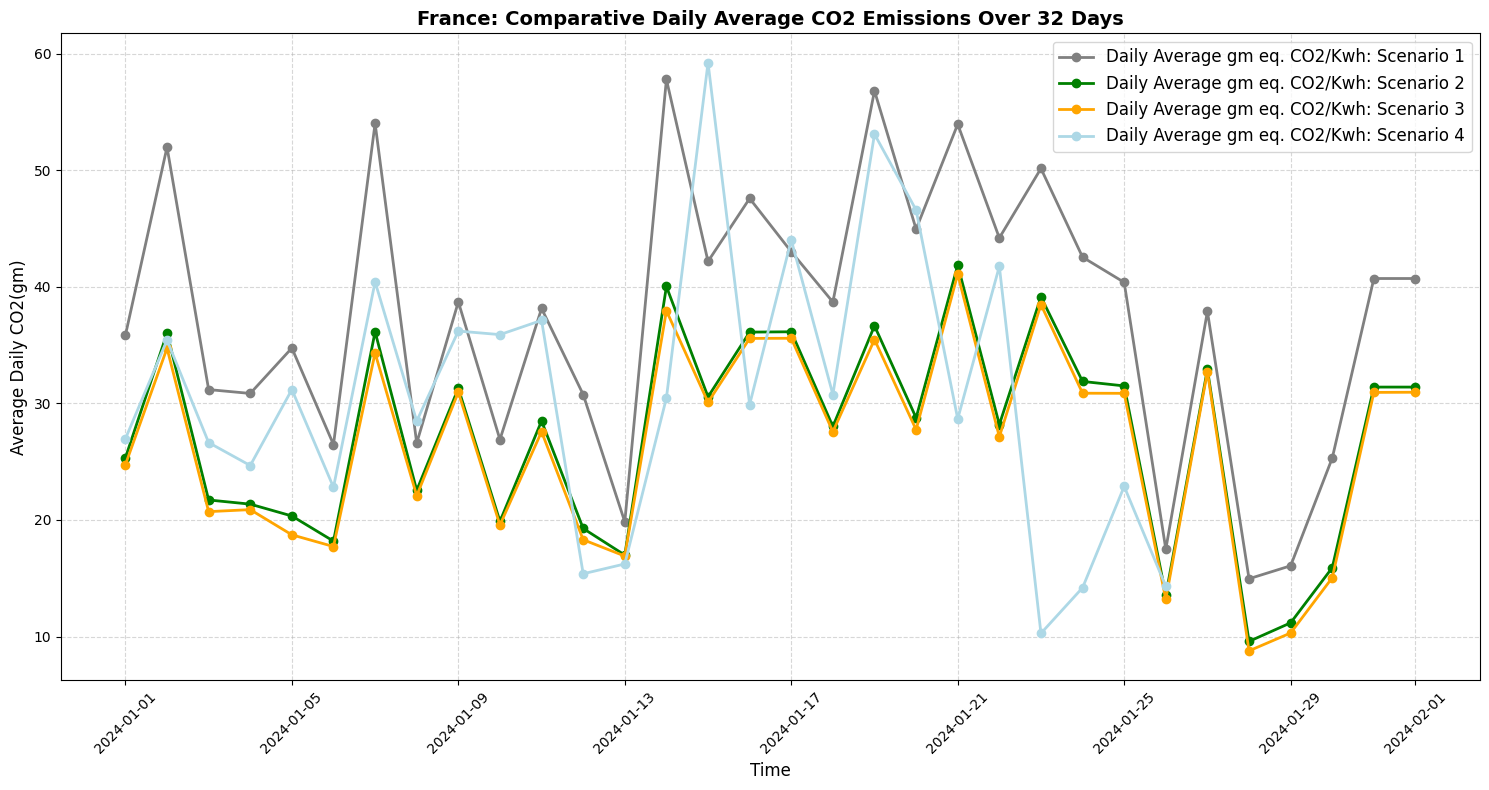

In [41]:
def daily_data(time_index, data):
    daily_time = []
    daily_data = []

    for i in range(0, len(data), 1440):
        daily_time.append(time_index[i])
        daily_data.append(np.mean(data[i:min(i+1440, len(data))]))
    
    return daily_time, daily_data

colors = ['grey', 'green', 'orange', 'lightblue']
labels = [
    'Daily Average gm eq. CO2/Kwh: Scenario 1',
    'Daily Average gm eq. CO2/Kwh: Scenario 2',
    'Daily Average gm eq. CO2/Kwh: Scenario 3',
    'Daily Average gm eq. CO2/Kwh: Scenario 4'
]

plt.figure(figsize=(15, 8))

for i, (time_index, result_df_grid) in enumerate([(time_index_1, result_df_grid_1), 
                                                  (time_index_2, result_df_grid_2), 
                                                  (time_index_3, result_df_grid_3), 
                                                  (time_index_4, result_df_grid_4)]):
    daily_time, daily_co2 = daily_data(time_index, result_df_grid[0].to_numpy())
    plt.plot(daily_time, daily_co2, linestyle='-', color=colors[i], linewidth=2, marker='o', label=labels[i])

plt.xlabel('Time', fontsize=12)
plt.ylabel('Average Daily CO2(gm)', fontsize=12)
plt.title('France: Comparative Daily Average CO2 Emissions Over 32 Days', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

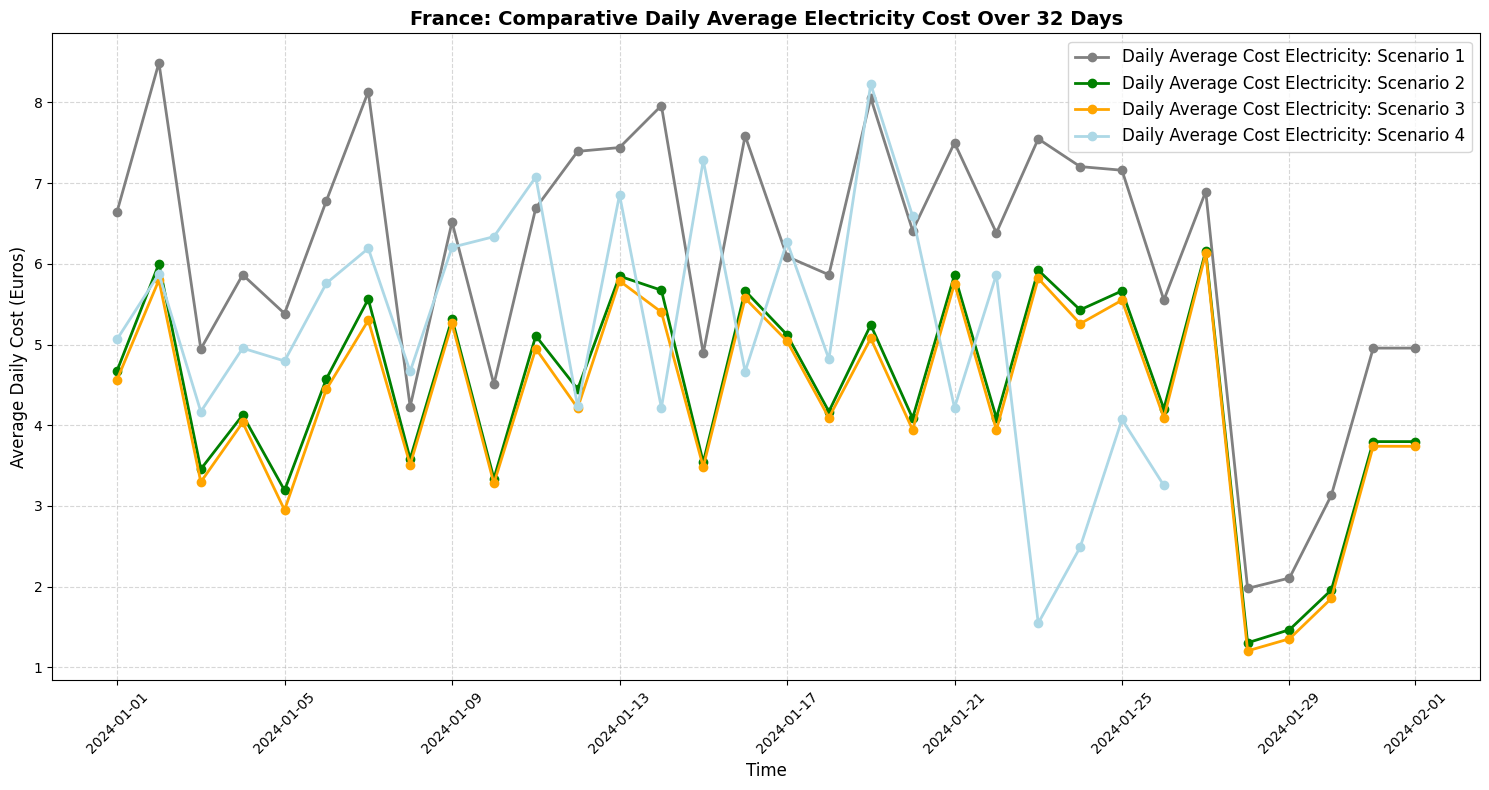

In [42]:
def daily_data(time_index, data):
    daily_time = []
    daily_data = []

    for i in range(0, len(data), 1440):
        daily_time.append(time_index[i])
        daily_data.append(np.sum(data[i:min(i+1440, len(data))]))
    
    return daily_time, daily_data

colors = ['grey', 'green', 'orange', 'lightblue']
labels = [
    'Daily Average Cost Electricity: Scenario 1',
    'Daily Average Cost Electricity: Scenario 2',
    'Daily Average Cost Electricity: Scenario 3',
    'Daily Average Cost Electricity: Scenario 4'
]

plt.figure(figsize=(15, 8))

for i, (time_index, cost_df) in enumerate([(time_index_1C, cost_df_1), 
                                           (time_index_2C, cost_df_2), 
                                           (time_index_3C, cost_df_3), 
                                           (time_index_4C, cost_df_4)]):
    daily_time, daily_cost = daily_data(time_index, cost_df[0].to_numpy())
    plt.plot(daily_time, daily_cost, linestyle='-', color=colors[i], linewidth=2, marker='o', label=labels[i])

plt.xlabel('Time', fontsize=12)
plt.ylabel('Average Daily Cost (Euros)', fontsize=12)
plt.title('France: Comparative Daily Average Electricity Cost Over 32 Days', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()